In [1]:
import sys
import os
sys.path.append('../')

import skimage
import microdet.mnds
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/mnt/cephfs/mir/jcaicedo/projects/micronuclei_detection/Train_and_Eval/BBBC039/metadata/filenames_and_plates.csv')
df

,IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB.png,20630
0,IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168A...,20586
1,IXMtest_A09_s1_w1CE70AD49-290D-4312-82E6-CDC71...,20630
2,IXMtest_A12_s7_w1EAEEA614-51ED-43B3-A4FF-08873...,20641
3,IXMtest_A15_s5_w1825174D4-ED30-490C-9635-61964...,20625
4,IXMtest_A16_s2_w15AF20A10-82AE-48FA-AC50-7AE8A...,20608
...,...,...
194,IXMtest_P21_s4_w19B7DC88B-10BB-4B51-9A10-9E302...,20633
195,IXMtest_P21_s5_w1ACEBEE91-BAFA-49E6-9D97-D0719...,20641
196,IXMtest_P23_s7_w13B627CB9-6C57-4049-AAD7-6468A...,20589
197,IXMtest_P23_s9_w1CA355675-EEC7-40B6-82C8-DC7E5...,20639


In [2]:
directory = '/scr/yren/micronuclei-detection/microdet/all_data_micronuclei_no_rescale/train'
scale_factor = 1.0
files = os.listdir(directory)
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('.phenotype_outlines.png')]
annot_files.sort()

training_files = annot_files.copy()

In [13]:
training_files

['2022-03-18_RPE1-3.phenotype_outlines.png',
 '2022-03-18_RPE1-4.phenotype_outlines.png',
 '2022-03-18_RPE1-5.phenotype_outlines.png',
 '2022-04-14_RPE1-2.phenotype_outlines.png',
 '2022-04-14_RPE1-2198.phenotype_outlines.png',
 '2022-04-14_RPE1-5.phenotype_outlines.png',
 '2022-05-25_RPE1-1.phenotype_outlines.png',
 '2022-05-25_RPE1-2.phenotype_outlines.png',
 '2022-05-25_RPE1-3.phenotype_outlines.png',
 '2022-05-26_RPE1-1.phenotype_outlines.png',
 '2022-05-26_RPE1-2.phenotype_outlines.png',
 '2022-05-27_RPE1-1.phenotype_outlines.png',
 '2022-05-27_RPE1-2197.phenotype_outlines.png',
 '2022-05-27_RPE1-3.phenotype_outlines.png',
 '2022-10-14_U2OS-1.phenotype_outlines.png',
 '2022-10-14_U2OS-10.phenotype_outlines.png',
 '2022-10-14_U2OS-3.phenotype_outlines.png',
 '2022-10-14_U2OS-5.phenotype_outlines.png',
 '2022-10-14_U2OS-7.phenotype_outlines.png',
 '2022-10-14_U2OS-9.phenotype_outlines.png',
 '2023-05-31_misc-1.phenotype_outlines.png',
 '2023-05-31_misc-10.phenotype_outlines.png',
 '

In [6]:
images = {}
for fname in tqdm(training_files):
    imid = fname.split('.')[0]
    im = microdet.mnds.read_image(directory, imid, 'phenotype.tif', scale_factor)
    im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32")
    #im = skimage.exposure.rescale_intensity(im, out_range=np.float32)
    mni = microdet.mnds.read_micronuclei_annotations(directory, imid)
    mnm = microdet.mnds.read_image(directory, imid, 'phenotype_outlines.png', scale_factor)
    nuc = microdet.mnds.read_nuclei_masks(directory, imid)
    # all_locs.append(mni)
    images[imid] = {"image":im, "micro":mnm, "nuclei":nuc, "loc":mni}

 29%|██▉       | 35/121 [00:20<00:50,  1.70it/s]


KeyboardInterrupt: 

In [3]:
training_set = microdet.mnds.MicronucleiDataset(
    filelist=training_files, 
    directory=directory, 
    mode="random",
    edges=False,
    transform=microdet.mnds.detection_transforms,
    scale_factor=scale_factor,
    patch_size=256,
    gaussian=True
)

100%|██████████| 121/121 [00:53<00:00,  2.28it/s]


In [4]:
train_dataloader = DataLoader(training_set, batch_size=32, shuffle=True)

In [5]:
print(len(train_dataloader))
print(len(training_set))

81
2580


In [5]:
for i, data in enumerate(train_dataloader):
    x, y = data
    print(x.shape)
    print(y.shape)

torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size([32, 2, 256, 256])
torch.Size([32, 3, 256, 256])
torch.Size

In [ ]:
im = skimage.io.imread('/scr/yren/all_data_micronuclei_no_rescale/train/2023-05-31_misc-10.phenotype.tif')
print(im.shape)

In [7]:
index = []
def randomize_patch_index():
        # shuffled += 1
        #print("Randomized",self.shuffled,"times")
        PS = 256
        
        for imid in images:
            # Generate random patch coordinates C
            H, W = images[imid]["image"].shape
            patches_per_image = (W // PS) * (H // PS)
            # print(f'{imid}: height - {H}, width - {W}, patches - {patches_per_image}')
            X = np.random.randint(0, W - PS, patches_per_image)
            Y = np.random.randint(0, H - PS, patches_per_image)
            C = np.stack((Y,X)).T
            A = {}

            # Micronuclei locations
            for k,r in images[imid]["loc"].iterrows():
                # Check whether the location r.x,r.y is covered by patches
                matches = np.where(np.logical_and( 
                            np.logical_and(C[:,0] < r.y, C[:,0] + PS > r.y),
                            np.logical_and(C[:,1] < r.x, C[:,1] + PS > r.x)
                ))
                matches = matches[0]
                if len(matches) > 0:
                    # Annotate all patches that cover the location
                    for m in matches:
                        try: A[m].append((r.y, r.x))
                        except: A[m] = [(r.y, r.x)]
                elif (r.y + PS < H and r.x + PS < W):
                elif (r.y + PS < H or r.x + PS < W): # or statement might fit non-square images?
                    # If not covered, add a new patch that covers the location
                    if (r.y == 0 and r.x == 0):
                        extra = [[0, 0]]
                    elif (r.x == 0 and r.y != 0):
                        extra = [[np.random.randint(max(r.y - PS,0), r.y), 0]]
                    elif (r.y == 0 and r.x != 0):
                        extra = [[0, np.random.randint(max(r.x - PS,0), r.x)]]
                    else:
                        if (r.y + PS < H and r.x + PS < W):
                            extra = [[np.random.randint(max(r.y - PS,0), r.y), np.random.randint(max(r.x - PS,0), r.x)]]
                        elif (r.y + PS < H and r.x + PS > W):
                            extra = [[np.random.randint(max(r.y - PS,0), r.y), W - PS]]
                        elif (r.y + PS > H and r.x + PS < W):
                            extra = [[H - PS, np.random.randint(max(r.x - PS,0), r.x)]]
                        elif (r.y + PS > H and r.x + PS > W):
                            extra = [[H - PS, W - PS]]

                    C = np.append(C, extra, axis=0)
                    if imid == '2022-10-14_U2OS-3':
                        print(r.y, r.x)
                        print(extra)
                        # print(C)
                        print('----')
                    A[C.shape[0]-1] = [(r.y, r.x)]

            # Put annotated patches in the index
            count = 0
            for k in A:
                index.append({"Image":imid, "coord": C[k,:].tolist(), "locs":A[k]})
                count += 1

            # Complete budget with non-annotated patches
            U = [x for x in range(patches_per_image) if x not in A]
            pointer = 0
            while count < patches_per_image:
                k = U[pointer]
                index.append({"Image":imid, "coord": C[k,:].tolist(), "locs":[]})
                pointer += 1
                count += 1
randomize_patch_index()

16 109
[[15, 51]]
----
60 20
[[43, 20]]
----
83 12
[[49, 3]]
----
189 3
[[117, 1]]
----
411 112
[[159, 74]]
----
590 391
[[512, 303]]
----
659 569
[[512, 567]]
----
715 301
[[460, 250]]
----
757 62
[[512, 15]]
----


In [ ]:
768 + 256

In [ ]:
gt = skimage.io.imread('/scr/yren/all_data_micronuclei_no_rescale/train/2023-05-31_misc-10.phenotype_outlines.png')
print(gt.shape)
plt.imshow(gt)

In [ ]:
index

In [ ]:
crop = im[512:512+256, 1:1+256]
print(crop.shape)

In [ ]:
print(im.shape)

In [ ]:
388 + 256

In [ ]:
for item in index:
    if item['Image'] == '2022-03-18_RPE1-3':
        im = images[item["Image"]]["image"]
        print(f'Original Shape: {im.shape}')
        r, c = int(item["coord"][0]), int(item["coord"][1])
        crop = images[item["Image"]]["image"][r:r+256,c:c+256]
        print(r, c)
        print(f'Crop Shape: {crop.shape}')

In [ ]:
539 + 256

In [ ]:
H, W = images[imid]["image"].shape
PS = 256
patches_per_image = (W // PS) * (H // PS)
X = np.random.randint(0, W - PS, patches_per_image)
Y = np.random.randint(0, H - PS, patches_per_image)
C = np.stack((Y,X)).T
# print(C)
# print('------------')
imid = '2022-03-18_RPE1-3'
index = []
A = {}
for k,r in images[imid]["loc"].iterrows():
    # Check whether the location r.x,r.y is covered by patches
    matches = np.where(np.logical_and( 
                np.logical_and(C[:,0] < r.y, C[:,0] + PS > r.y),
                np.logical_and(C[:,1] < r.x, C[:,1] + PS > r.x)
    ))
    matches = matches[0]
    if len(matches) > 0:
        # Annotate all patches that cover the location
        for m in matches:
            try: A[m].append((r.y, r.x))
            except: A[m] = [(r.y, r.x)]
    # elif (r.y + PS < H and r.x + PS < W):
    elif (r.y + PS < H or r.x + PS < W): # or statement might fit non-square images?
        # If not covered, add a new patch that covers the location
        if (r.y == 0 and r.x == 0):
            extra = [[0, 0]]
        elif (r.y != 0 and r.x == 0):
            extra = [[np.random.randint(max(r.y - PS,0), r.y), 0]]
        elif (r.y == 0 and r.x != 0):
            extra = [[0, np.random.randint(max(r.x - PS,0), r.x)]]
        else:
            if (r.y + PS < H and r.x + PS < W):
                extra = [[np.random.randint(max(r.y - PS,0), r.y), np.random.randint(max(r.x - PS,0), r.x)]]
            elif (r.y + PS < H and r.x + PS > W):
                extra = [[np.random.randint(max(r.y - PS,0), r.y), W - PS]]
            elif (r.y + PS > H and r.x + PS < W):
                extra = [[H - PS, np.random.randint(max(r.x - PS,0), r.x)]]
            elif (r.y + PS >H and r.x + PS > W):
                extra = [[H - PS, W - PS]]
        # print(extra)
        C = np.append(C, extra, axis=0)
        print(extra)
        A[C.shape[0]-1] = [(r.y, r.x)]
# Put annotated patches in the index
count = 0
for k in A:
    # print(C[k,:].tolist())
    index.append({"Image":imid, "coord": C[k,:].tolist(), "locs":A[k]})
    count += 1

# Complete budget with non-annotated patches
U = [x for x in range(patches_per_image) if x not in A]
pointer = 0
while count < patches_per_image:
    # print(C[k,:].tolist())
    k = U[pointer]
    index.append({"Image":imid, "coord": C[k,:].tolist(), "locs":[]})
    pointer += 1
    count += 1

Original Shape: (768, 869)

In [ ]:
607 + 256

In [ ]:
for item in index:
    print(item['coord'])

In [ ]:
index

In [ ]:
554 + 256

In [ ]:
585 + 256

In [ ]:
A

In [3]:
df = pd.read_csv('/scr/yren/all_data_micronuclei_no_rescale/metadata.csv')
df

,filenames,datasets,magnification,micron,split
0,C1-20X_c0_B3_Tile-5.phenotype.tif,HeLa,20,6.5,train
1,C1-20X_c0_B3_Tile-24.phenotype.tif,HeLa,20,6.5,validation
2,C1-20X_c0_B3_Tile-15.phenotype.tif,HeLa,20,6.5,test
3,C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif,RPE1,20,6.5,train
4,C1-20X_c0_phalloidin_C3_Tile-15.phenotype.tif,RPE1,20,6.5,validation
...,...,...,...,...,...
227,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,20,13.1,train
228,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,20,13.1,train
229,IXMtest_M12_s7_w193E9BA0F-274A-4EE8-A0F0-6A584...,BBBC039,20,13.1,test
230,IXMtest_I11_s6_w1B2DC04C7-2D7D-45C6-9DC2-66D86...,BBBC039,20,13.1,validation


In [10]:
subset = 'mnfinder_train'
if subset == 'pilot_screen':
    files_to_remove = df[df.datasets.isin(['pilot', 'screen'])]
elif subset == 'hela_rpe1':
    files_to_remove = df[df.datasets.isin(['HeLa', 'RPE1'])]
else:
    files_to_remove = df[df.datasets.isin([subset])]
files_to_remove

,filenames,datasets,magnification,micron,split
24,2022-05-27_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
25,2022-05-27_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
26,2022-05-27_RPE1-2197.phenotype.tif,mnfinder_train,20,11.0,train
27,2022-03-18_RPE1-3.phenotype.tif,mnfinder_train,20,11.0,train
28,2022-03-18_RPE1-5.phenotype.tif,mnfinder_train,20,11.0,train
29,2022-03-18_RPE1-4.phenotype.tif,mnfinder_train,20,11.0,train
30,2022-05-26_RPE1-2.phenotype.tif,mnfinder_train,20,11.0,train
31,2022-05-26_RPE1-1.phenotype.tif,mnfinder_train,20,11.0,train
32,2023-05-31_misc-10.phenotype.tif,mnfinder_train,20,11.0,train
33,2023-05-31_misc-11.phenotype.tif,mnfinder_train,20,11.0,train


In [2]:
pred = np.load('/scr/yren/H97Q2GHESJP9o8Vc5bS8_2D_img02095-LOC-2d-960-1440_1920-2400._probabilities.npy')

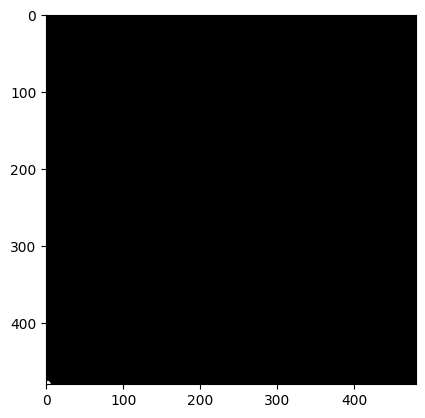

In [4]:
plt.imshow(pred, cmap='gray')